In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../dataset/cleaned_transactions.csv")

In [5]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   transaction_id      250000 non-null  object
 1   timestamp           250000 non-null  object
 2   transaction_type    250000 non-null  object
 3   merchant_category   250000 non-null  object
 4   amount_inr          250000 non-null  int64 
 5   transaction_status  250000 non-null  object
 6   sender_age_group    250000 non-null  object
 7   receiver_age_group  250000 non-null  object
 8   sender_state        250000 non-null  object
 9   sender_bank         250000 non-null  object
 10  receiver_bank       250000 non-null  object
 11  device_type         250000 non-null  object
 12  network_type        250000 non-null  object
 13  fraud_flag          250000 non-null  int64 
 14  hour_of_day         250000 non-null  int64 
 15  day_of_week         250000 non-null  object
 16  is

In [ ]:
#Sender Age Group Distribution
sender_age = (
    df.groupby("sender_age_group")
      .size()
      .reset_index(name="transactions")
      .sort_values("transactions", ascending=False)
)

sender_age

,sender_age_group,transactions
1,26-35,87432
2,36-45,62873
0,18-25,62345
3,46-55,24841
4,56+,12509


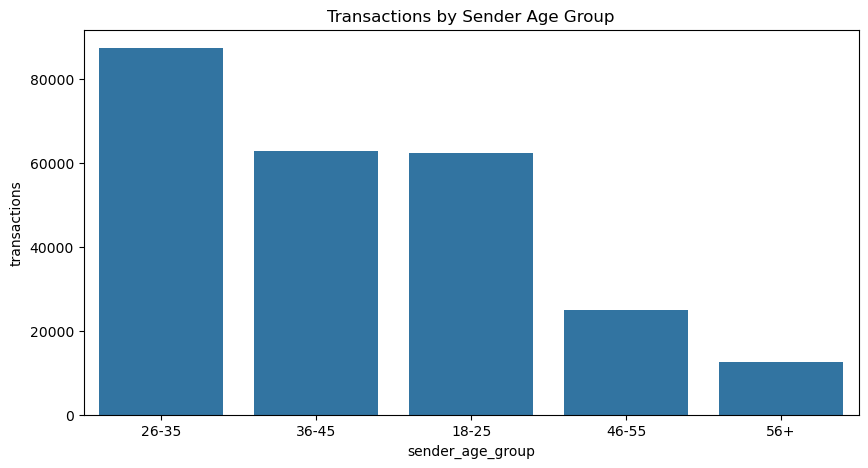

In [7]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=sender_age,
    x="sender_age_group",
    y="transactions"
)

plt.title("Transactions by Sender Age Group")
plt.show()

In [9]:
#Receiver Age Group Distribution
receiver_age = (
    df.groupby("receiver_age_group")
      .size()
      .reset_index(name="transactions")
)

receiver_age

#Spending by Age Group
age_spend = (
    df.groupby("sender_age_group")["amount_inr"]
      .sum()
      .reset_index()
      .sort_values("amount_inr", ascending=False)
)

age_spend

#Average Transaction Amount by Age Group
avg_age_spend = (
    df.groupby("sender_age_group")["amount_inr"]
      .mean()
      .reset_index()
      .sort_values("amount_inr", ascending=False)
)

avg_age_spend

#Most Active States
state_usage = (
    df.groupby("sender_state")
      .size()
      .reset_index(name="transactions")
      .sort_values("transactions", ascending=False)
)

state_usage.head(10)

#Highest Spending States
state_spending = (
    df.groupby("sender_state")["amount_inr"]
      .sum()
      .reset_index()
      .sort_values("amount_inr", ascending=False)
)

state_spending.head(10)

#User Behavior by Day
day_usage = (
    df.groupby("day_of_week")
      .size()
      .reset_index(name="transactions")
)

day_usage


#User Behavior by Hour
hour_usage = (
    df.groupby("hour_of_day")
      .size()
      .reset_index(name="transactions")
)

hour_usage


,hour_of_day,transactions
0,0,3388
1,1,2244
2,2,1685
3,3,1314
4,4,1247
5,5,1742
6,6,3501
7,7,5630
8,8,8349
9,9,10450


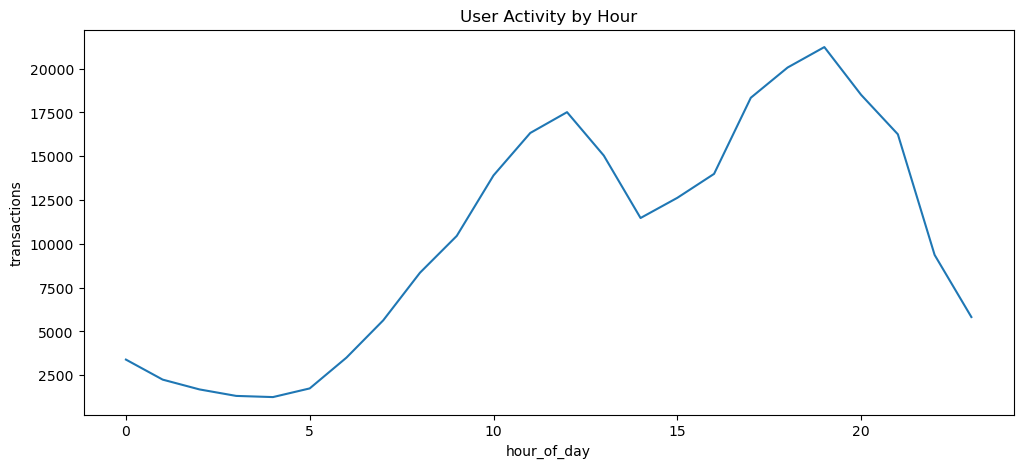

In [10]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=hour_usage,
    x="hour_of_day",
    y="transactions"
)

plt.title("User Activity by Hour")
plt.show()

In [11]:
#Weekend vs Weekday Usage
weekend_usage = (
    df.groupby("is_weekend")
      .size()
      .reset_index(name="transactions")
)

weekend_usage

,is_weekend,transactions
0,0,178663
1,1,71337


In [12]:
#Bank Preference Analysis
sender_bank_usage = (
    df.groupby("sender_bank")
      .size()
      .reset_index(name="transactions")
      .sort_values("transactions", ascending=False)
)

sender_bank_usage.head(10)

,sender_bank,transactions
6,SBI,62693
1,HDFC,37485
2,ICICI,29769
3,IndusInd,25173
0,Axis,25042
5,PNB,24946
7,Yes Bank,24860
4,Kotak,20032


In [13]:
#Average Spend by Bank
bank_spend = (
    df.groupby("sender_bank")["amount_inr"]
      .mean()
      .reset_index()
      .sort_values("amount_inr", ascending=False)
)

bank_spend.head(10)

,sender_bank,amount_inr
1,HDFC,1328.296492
6,SBI,1320.985118
4,Kotak,1313.668730
7,Yes Bank,1307.018383
3,IndusInd,1304.680054
5,PNB,1301.890964
2,ICICI,1301.057913
0,Axis,1296.722706


In [14]:
#Fraud by Age Group
fraud_age = (
    df.groupby("sender_age_group")["fraud_flag"]
      .sum()
      .reset_index()
      .sort_values("fraud_flag", ascending=False)
)

fraud_age

,sender_age_group,fraud_flag
1,26-35,163
0,18-25,143
2,36-45,116
3,46-55,31
4,56+,27


In [15]:
#Fraud by State
fraud_state = (
    df.groupby("sender_state")["fraud_flag"]
      .sum()
      .reset_index()
      .sort_values("fraud_flag", ascending=False)
)

fraud_state.head(10)

,sender_state,fraud_flag
4,Maharashtra,71
3,Karnataka,69
8,Uttar Pradesh,52
1,Delhi,50
5,Rajasthan,46
2,Gujarat,43
6,Tamil Nadu,40
7,Telangana,39
0,Andhra Pradesh,35
9,West Bengal,35


In [16]:
#User Segmentation
conditions = [
    df["amount_inr"] < 1000,
    (df["amount_inr"] >= 1000) &
    (df["amount_inr"] < 5000),
    (df["amount_inr"] >= 5000) &
    (df["amount_inr"] < 20000),
    df["amount_inr"] >= 20000
]

labels = [
    "Low Usage",
    "Medium Usage",
    "High Usage",
    "Power User"
]

df["user_segment"] = pd.cut(
    df["amount_inr"],
    bins=[0,1000,5000,20000,float("inf")],
    labels=labels
)
df["user_segment"].value_counts()

user_segment
Low Usage       157661
Medium Usage     81383
High Usage       10856
Power User         100
Name: count, dtype: int64

Segment Analysis

In [17]:
segment_summary = (
    df.groupby("user_segment")
      .agg(
          transactions=("transaction_id","count"),
          total_amount=("amount_inr","sum"),
          avg_amount=("amount_inr","mean")
      )
      .reset_index()
)

segment_summary

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12156\1399244372.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("user_segment")


,user_segment,transactions,total_amount,avg_amount
0,Low Usage,157661,63851728,404.993803
1,Medium Usage,81383,178616680,2194.766475
2,High Usage,10856,83028946,7648.207996
3,Power User,100,2441655,24416.550000


In [18]:
#High Value Users Proxy
high_value_groups = (
    df.groupby("sender_age_group")["amount_inr"]
      .sum()
      .reset_index()
      .sort_values("amount_inr", ascending=False)
)

high_value_groups

,sender_age_group,amount_inr
1,26-35,115959771
2,36-45,89533745
0,18-25,74473936
3,46-55,33116261
4,56+,14855296


In [19]:
#Create User Summary
user_summary = (
    df.groupby(
        ["sender_age_group","sender_state"]
    )
    .agg(
        transaction_count=("transaction_id","count"),
        total_spend=("amount_inr","sum"),
        avg_spend=("amount_inr","mean"),
        fraud_count=("fraud_flag","sum")
    )
    .reset_index()
)

user_summary.head()

,sender_age_group,sender_state,transaction_count,total_spend,avg_spend,fraud_count
0,18-25,Andhra Pradesh,4991,5999132,1201.989982,10
1,18-25,Delhi,6170,7532944,1220.898541,11
2,18-25,Gujarat,4980,5805711,1165.805422,19
3,18-25,Karnataka,7344,8778267,1195.297794,24
4,18-25,Maharashtra,9418,11364225,1206.649501,23


In [21]:
user_summary.to_csv(
    "../dataset/user_summary.csv",
    index=False
)
segment_summary.to_csv(
    "../dataset/user_segments.csv",
    index=False
)
